## 깔끔한 데이터 만들기
> 데이터분석을 용이하게 하고 시각화를 수월하게 하기 위해서 데이터프레임이 깔끔한 구조를 가지는 것이 좋음.


깔끔한 데이터란? - 
1. 변수는 column(열)로 구성
2. 관측값은 row(행)로 구성
3. 값은 cell(셀)에 작성

위 규칙에 맞지 않게 만들어져 있는 데이터셋이 있다면 구조를 변경하여 깔끔한 데이터프레임으로 만들어서 분석함.

**사례별로 구조를 변경하면 깔끔한 데이터를 만들어보기**

In [1]:
#1. 열 이름이 관측값일 경우...(안좋은 구조)
# 비 깔끔한 데이터
import pandas as pd
data = [
    ["서울", 10, 12, 15],
    ["부산", 7, 9, 11]
]

df = pd.DataFrame(data, columns=["지역", "2021", "2022", "2023"])
df

,지역,2021,2022,2023
0,서울,10,12,15
1,부산,7,9,11


In [3]:
#문제1. 연도별 평균 판매액 구하기
df[['2021','2022','2023']].mean()
# 문제점.
# 연도 컬룸명을 직접 나열해야함.
# 연도를 변수처럼 다루지 않아서...직관적이지 않음.

2021     8.5
2022    10.5
2023    13.0
dtype: float64

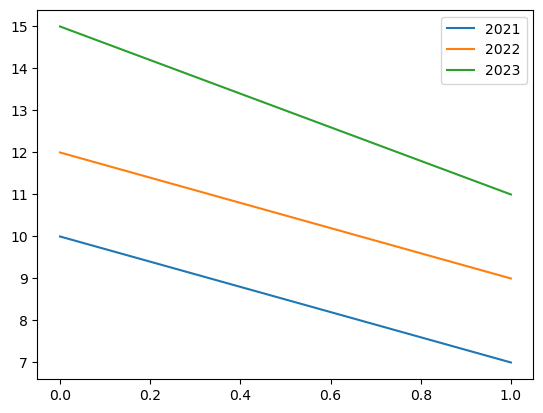

In [6]:
#문제2. 시각화 할때 짜증 -- 뭔지 잘 안 읽어짐
#통상적으로 그래프를 그릴때..
#관측값들이  x축
#각 변수의 값들이 y축

#연도별 추이를 그리고 싶어...
import matplotlib.pyplot as plt

plt.plot(df['2021'], label='2021')
plt.plot(df['2022'], label='2022')
plt.plot(df['2023'], label='2023')
plt.legend()
plt.show()

In [8]:
#깔끔한 데이터로 변경.. 방법 [ .melt() ]
df_tidy = df.melt(
    id_vars='지역',      # 그대로 유지될 컬룸 지정
    value_vars=['2021','2022','2023'],  #'녹여서' 행으로 변환될 컬룸명등.(지정하지 않으면 모두)
    var_name='연도',      # 기존 컬룸명이 값이된 컬룸의 이름지정
    value_name='매출액'  # 값들이 들어간 컬룸의 이름지정
)
df_tidy

,지역,연도,매출액
0,서울,2021,10
1,부산,2021,7
2,서울,2022,12
3,부산,2022,9
4,서울,2023,15
5,부산,2023,11


In [9]:
#지역 기준으로 내림차순
df= df_tidy.sort_values(by=['지역'], ascending=False)
df

,지역,연도,매출액
0,서울,2021,10
2,서울,2022,12
4,서울,2023,15
1,부산,2021,7
3,부산,2022,9
5,부산,2023,11


In [10]:
df= df.reset_index(drop=True)
df

,지역,연도,매출액
0,서울,2021,10
1,서울,2022,12
2,서울,2023,15
3,부산,2021,7
4,부산,2022,9
5,부산,2023,11


In [11]:
# 연도별 매출액 평균
df.groupby('연도')['매출액'].mean()

연도
2021     8.5
2022    10.5
2023    13.0
Name: 매출액, dtype: float64

In [12]:
#특정 연도 필터링
df[ df['연도']=='2022' ]

,지역,연도,매출액
1,서울,2022,12
4,부산,2022,9


<Axes: xlabel='연도', ylabel='매출액'>

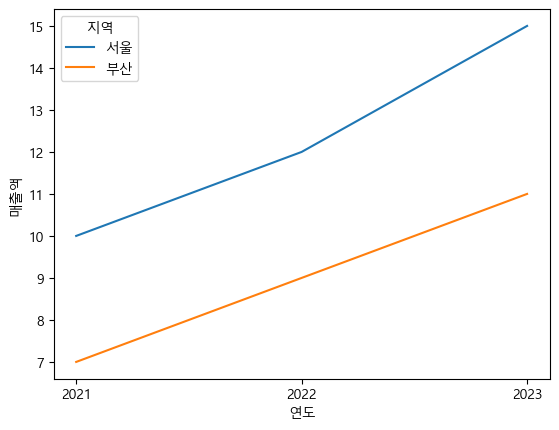

In [14]:
# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family']= 'Malgun Gothic'

sns.lineplot(data= df, x='연도', y='매출액', hue='지역')

In [15]:
# 분석 및 집계가 끝나면 melt했던 데이터프레임의 행렬을 원위치 할 수도 있음(행<->열)
df_again= df.pivot(
    index='지역',
    columns='연도',
    values='매출액'
)
df_again

연도,2021,2022,2023
지역,,,
부산,7,9,11
서울,10,12,15


In [16]:
#사례2. 하나의 셀에 여러개의 값이 있는 경우.
# 원래 데이터
df= pd.DataFrame([
    ['철수', '남_20'],
    ['영희', '여_22'],
], columns=['이름','성별_나이'])
df

,이름,성별_나이
0,철수,남_20
1,영희,여_22


In [18]:
# 성별 나이를 분리하여 각각의 컬룸에 넣기
df[['성별','나이']]= df['성별_나이'].str.split('_', expand=True) #결과를 파이썬 리스트
#expand=True : 나눈 결과를 리스트 형태가 아닌, 여러개의 새로운 컬룸을 가진 데이터프레임으로 반환
df

,이름,성별_나이,성별,나이
0,철수,남_20,남,20
1,영희,여_22,여,22


In [19]:
#사례3. 구조는 좋은데.. 중복 데이터가 너무 많아서...집계해서 관리..
#예제 데이터 (깔끔한 데이터지만 중복 존재)
import pandas as pd

df = pd.DataFrame({
    "지역": ["서울","서울","서울","부산","부산","부산"],
    "연도": [2021, 2021, 2022, 2021, 2022, 2022],
    "월":   [1, 2, 1, 1, 1, 2],
    "판매액": [5, 7, 12, 7, 9, 11]
})

df

,지역,연도,월,판매액
0,서울,2021,1,5
1,서울,2021,2,7
2,서울,2022,1,12
3,부산,2021,1,7
4,부산,2022,1,9
5,부산,2022,2,11


In [20]:
# 지역별 , 연도별롤 묶어서 매출액의 총합, 평균을 집계한 데이터프레임으로 변경
df2= df.pivot_table(
    index='지역',
    columns='연도',
    values='판매액',
    aggfunc=['sum', 'mean']    
)
df2

sum      mean      
연도 2021 2022 2021  2022
지역                     
부산    7   20  7.0  10.0
서울   12   12  6.0  12.0

## 수행과제 : chapter 03, 05, 11 읽고 예제 따라하기!